# Data Reconciliation of a Gas Transmission Network

Plant measurements disagree with the model. Meters drift, nominations do not close, and
a pressure drop rarely matches the flow that supposedly caused it. **Data reconciliation**
finds the smallest statistically weighted adjustment that makes the measurements satisfy
the model equations:

$$\min_x \; (x - y)^T W (x - y) \quad \text{subject to} \quad F(x, \theta) = 0$$

The payoff is not just consistency. Because the model equations carry information the
sensors do not, the reconciled estimates are **more precise than the measurements** --- on
the network below, by 58% to 93% in variance.

Everything reconciliation needs is derivative information: the constraint Jacobian $A =
\partial F/\partial x$, the covariance of the estimates, the sensitivity of each estimate
to each measurement. A conventional flowsheet package hand-derives it unit by unit. Here
`jax.jacobian` supplies it, which is what makes the same code work for a gas network, a
reactor train, or an equation set you write on the spot.

**What this notebook covers**

1. The network and its true state
2. Corrupting it, and seeing the model reject the data
3. Reconciliation, and the precision it buys
4. Covariance two ways: the textbook formula and autodiff
5. Finding a biased flow meter
6. Estimating an unmeasured pipe fouling factor
7. The observability boundary --- and what the compressor has to do with it
8. Sensor placement

## 1. Setup

In [1]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
import difflow_gas as dg
from difflow_gas import verify
from difflow.reconciliation import (
    global_test,
    measurement_test,
    measurement_sensitivity,
    reconciled_covariance,
    sensor_ranking,
    serial_elimination,
    solve_reconciliation,
    ReconciliationStructureError,
)

# palette: categorical slots 1-2, plus the reserved "critical" status step
BLUE, ORANGE, RED, GREY = "#2a78d6", "#eb6834", "#d03b3b", "#8a8985"
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#eceae6"

def tidy(ax, axis="y"):
    """Recessive axes and grid, so the data carries the emphasis."""
    ax.spines[["top", "right"]].set_visible(False)
    for s in ax.spines.values():
        s.set_color("#d5d4d0")
    ax.tick_params(colors=INK_SOFT, labelsize=8, length=3)
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

print("JAX version:", jax.__version__)

JAX version: 0.10.2


## 2. The network

Five nodes, one compressor station, and a loop. Gas enters at `src` at 120 kg/s, is boosted
by station `cs1`, and leaves at `c` (50 kg/s) and `d` (70 kg/s). Arcs `p2`, `p3` and `p4`
form the loop `b-c-d-b`, which is what creates redundancy: the flow split around a loop is
determined by the pipe resistances, so measuring it over-determines the state.

This is the network of `20_gas_network_flowsheets.ipynb`, with realistic Weymouth
coefficients for 0.6 m pipes at transmission scale.

In [2]:
RATIOS = {"cs1": 1.2}          # compressor pressure ratio
P_SLACK_PA = 60.0e5           # slack pressure at src (60 bar)

net = dg.GasNetwork(
    arcs={
        "p1":  ("src", "a", "pipe"),
        "cs1": ("a",   "b", "compressor"),
        "p2":  ("b",   "c", "pipe"),
        "p3":  ("b",   "d", "pipe"),
        "p4":  ("c",   "d", "pipe"),        # closes the loop b-c-d-b
    },
    beta={
        aid: dg.weymouth_beta(length_m=L, diameter_m=0.6, roughness_m=1e-4)
        for aid, L in [("p1", 20e3), ("p2", 40e3), ("p3", 60e3), ("p4", 80e3)]
    },
    supply_kg_s={"src": 120.0, "c": -50.0, "d": -70.0},
    pressure_bounds_bar={n: (30.0, 80.0) for n in ["src", "a", "b", "c", "d"]},
)

print(f"{len(net.nodes)} nodes, {len(net.arcs)} arcs, cycle rank {net.cycle_rank}")

5 nodes, 5 arcs, cycle rank 1


Solve it sequentially to get the true state that the measurements will be sampled around.

In [3]:
fs, dec = dg.build_network_flowsheet(
    net, root="src", p_slack_pa=P_SLACK_PA, ratios=RATIOS
)
streams = fs.solve(tol=1e-12, max_iter=500)

p_true = verify.node_pressures_bar(streams, dec)
q_true = verify.arc_flows_kg_s(streams, dec)

print("pressures (bar):", {k: round(v, 3) for k, v in p_true.items()})
print("flows (kg/s)   :", {k: round(v, 3) for k, v in q_true.items()})
print("all equations satisfied:", verify.residual_report(streams, net, dec).ok)

pressures (bar): {'src': 60.0, 'a': 51.624, 'b': 61.948, 'c': 57.406, 'd': 56.921}
flows (kg/s)   : {'p1': 120.0, 'cs1': 120.0, 'p2': 64.612, 'p3': 55.388, 'p4': 14.612}
all equations satisfied: True


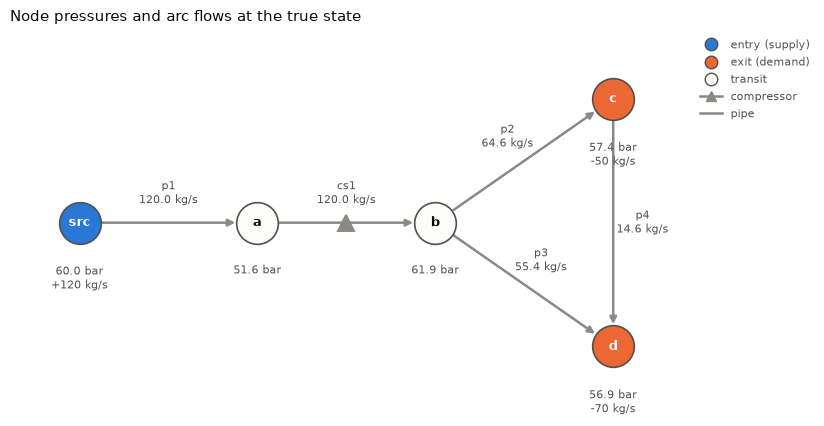

In [4]:
POS = {"src": (0, 0), "a": (1.15, 0), "b": (2.3, 0),
       "c": (3.45, 0.8), "d": (3.45, -0.8)}

fig, ax = plt.subplots(figsize=(8.5, 4.4))
dg.draw_network(
    net, ax=ax, pos=POS, pressures=p_true, flows=q_true,
    title="Node pressures and arc flows at the true state",
)
plt.tight_layout()
plt.show()

### The state vector

`gas_state_layout` packs pressures (bar), signed arc flows (kg/s) and **boundary flows**
into one vector. The boundary flows being *variables* rather than fixed parameters matters
more than it looks: with them held fixed, the node-balance block of the Jacobian is the
network's incidence matrix, whose rank is only $n_{\text{nodes}} - 1$, and the KKT system
below would be singular for purely structural reasons. Carrying them as unknowns gives every
balance row a $+1$ in its own column.

It also reflects reality. Real nominations do not sum to zero --- and `GasNetwork` refuses
to store supplies that do not. So the measured nominations live in the measurement vector,
and making them close is precisely the reconciliation's job.

In [5]:
layout = dg.gas_state_layout(net)
residual_fn = dg.network_residual_fn(net, layout, ratios=RATIOS)

x_true = layout.pack(p_true, q_true, net.supply_kg_s)

print(f"{layout.size} variables:", layout.names)
print(f"\n{len(dg.residual_names(net, layout))} equations:", dg.residual_names(net, layout))
print("\nF(x_true) max residual:", float(jnp.max(jnp.abs(residual_fn(x_true)))))

13 variables: ['p_a', 'p_b', 'p_c', 'p_d', 'p_src', 'q_cs1', 'q_p1', 'q_p2', 'q_p3', 'q_p4', 's_c', 's_d', 's_src']

10 equations: ['balance_a', 'balance_b', 'balance_c', 'balance_d', 'balance_src', 'resistance_p1', 'resistance_p2', 'resistance_p3', 'resistance_p4', 'compressor_cs1']

F(x_true) max residual: 1.2986518527213775e-09


Note the last equation. `difflow_gas.verify` deliberately omits the compressor relation
$p_{\text{to}} = r\,p_{\text{from}}$, because a sequential solve satisfies it by
construction --- there is nothing to check. A reconciliation formulation *cannot* omit it:
without that row the pressures downstream of the station are untied from the ones upstream.
Section 7 shows it is exactly what makes the loop observable.

## 3. Corrupting the data

Real transmission practice: pressure transmitters are good, flow meters less so, and
nominated boundary flows are the least reliable numbers in the system.

In [6]:
sigma = dg.measurement_sigma(
    layout,
    sigma_p_bar=0.3,          # pressure transmitters
    sigma_q_kg_s=1.0,         # flow meters
    sigma_supply_kg_s=1.5,    # nominations
)
y = dg.perturb(x_true, sigma, jax.random.PRNGKey(0))

measured_p = {n: float(y[layout.index(f"p_{n}")]) for n in layout.nodes}
measured_q = {a: float(y[layout.index(f"q_{a}")]) for a in layout.arcs}
before = verify.residuals_from_values(measured_p, measured_q, net)

print(f"worst node imbalance   : {before.max_node_imbalance_kg_s:8.4f} kg/s")
print(f"worst resistance error : {before.max_resistance_residual_bar2:8.4f} bar^2")
nomination_sum = sum(float(y[layout.index(f"s_{n}")]) for n in layout.supply_nodes)
print(f"\nnominations sum to     : {nomination_sum:8.4f} kg/s  (should be 0)")

worst node imbalance   :   1.5623 kg/s
worst resistance error :  97.6610 bar^2

nominations sum to     :  -0.2062 kg/s  (should be 0)


The raw measurements are physically impossible: gas appears and disappears at nodes, and
the pipe laws are off by tens of bar². Every number is individually plausible; collectively
they are not.

## 4. Reconciliation

One call. `sigma` sets the weights, and the returned object carries the reconciled state,
its covariance, and the observability structure.

In [7]:
res = dg.reconcile_network(net, y, sigma, layout, ratios=RATIOS)
print(res.summary())

objective 8.753 on 10 degrees of redundancy, |F| = 4.55e-13, converged = True

variable                 measured   reconciled     adjust     sigma    sd_hat
----------------------------------------------------------------------------
p_a                       51.5620      51.6985     0.1365    0.3000    0.1174
p_b                       61.7130      62.0382     0.3252    0.3000    0.1409
p_c                       57.9511      57.4973    -0.4538    0.3000    0.1565
p_d                       56.9776      56.9743    -0.0033    0.3000    0.1585
p_src                     60.0243      60.1001     0.0758    0.3000    0.1266
q_cs1                    119.6279     120.2752     0.6473    1.0000    0.5348
q_p1                     121.1902     120.2752    -0.9150    1.0000    0.5348
q_p2                      64.9507      64.6521    -0.2986    1.0000    0.3254
q_p3                      55.4728      55.6231     0.1503    1.0000    0.2718
q_p4                      13.7402      15.1823     1.4421    1.0

In [8]:
p_rec, q_rec, s_rec = dg.reconciled_values(res, layout)
after = verify.residuals_from_values(p_rec, q_rec, net)

print(f"worst resistance error : {after.max_resistance_residual_bar2:.3e} bar^2"
      f"   (was {before.max_resistance_residual_bar2:.4f})")
print(f"nominations sum to     : {sum(s_rec.values()):.3e} kg/s")
print(f"\nreconciled by the plugin's own verifier: consistent")

worst resistance error : 1.298e-09 bar^2   (was 97.6610)
nominations sum to     : 1.421e-14 kg/s

reconciled by the plugin's own verifier: consistent


### What the constraints bought

The reconciled standard deviations come from $\Sigma_{\hat x} = [K^{-1}]_{11}$, the leading
block of the inverse KKT matrix. Every estimate is sharper than its measurement, and nothing
was measured twice --- the improvement comes entirely from the model.

In [9]:
print(f"{'variable':<10} {'sigma':>8} {'sd_hat':>8} {'variance reduction':>20}")
print("-" * 50)
for i, name in enumerate(layout.names):
    s0, s1 = float(sigma[i]), res.std[name]
    print(f"{name:<10} {s0:8.3f} {s1:8.4f} {100 * (1 - (s1 / s0) ** 2):17.1f} %")

variable      sigma   sd_hat   variance reduction
--------------------------------------------------
p_a           0.300   0.1174              84.7 %
p_b           0.300   0.1409              77.9 %
p_c           0.300   0.1565              72.8 %
p_d           0.300   0.1585              72.1 %
p_src         0.300   0.1266              82.2 %
q_cs1         1.000   0.5348              71.4 %
q_p1          1.000   0.5348              71.4 %
q_p2          1.000   0.3254              89.4 %
q_p3          1.000   0.2718              92.6 %
q_p4          1.000   0.6456              58.3 %
s_c           1.500   0.8258              69.7 %
s_d           1.500   0.8190              70.2 %
s_src         1.500   0.5348              87.3 %


The same two facts as pictures --- the adjustments on the left, and what they bought on the right. Flows are shown in units of each sensor's own $\sigma$ so that pressures, flows and nominations are comparable on one axis.

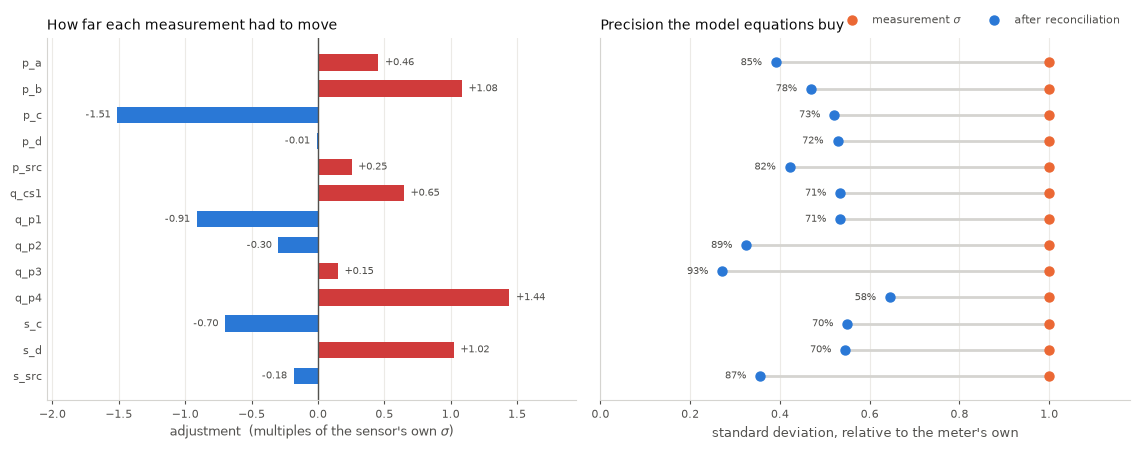

In [10]:
names = list(layout.names)
ypos = np.arange(len(names))[::-1]
adj_sigma = np.asarray(res.adjustment) / np.asarray(sigma)   # in sigma units
sd_ratio = np.array([res.std[n] for n in names]) / np.asarray(sigma)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)

ax = axes[0]
ax.barh(ypos, adj_sigma, height=0.62,
        color=[BLUE if v < 0 else RED for v in adj_sigma], edgecolor="none")
ax.axvline(0, color=INK_SOFT, linewidth=1)
ax.set_yticks(ypos)
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("adjustment  (multiples of the sensor's own $\\sigma$)",
              fontsize=9, color=INK_SOFT)
ax.set_title("How far each measurement had to move", fontsize=10, color=INK, loc="left")
for yy, v in zip(ypos, adj_sigma):
    ax.text(v + (0.05 if v >= 0 else -0.05), yy, f"{v:+.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=7.5, color=INK_SOFT)
ax.set_xlim(min(adj_sigma.min() * 1.35, -0.6), max(adj_sigma.max() * 1.35, 0.6))
tidy(ax, axis="x")
ax.tick_params(axis="y", length=0)

ax = axes[1]
ax.hlines(ypos, sd_ratio, 1.0, color="#d5d4d0", linewidth=2, zorder=1)
ax.scatter(np.ones_like(sd_ratio), ypos, s=42, color=ORANGE, zorder=2,
           label="measurement $\\sigma$")
ax.scatter(sd_ratio, ypos, s=42, color=BLUE, zorder=3, label="after reconciliation")
ax.set_xlim(0, 1.18)
ax.set_xlabel("standard deviation, relative to the meter's own",
              fontsize=9, color=INK_SOFT)
ax.set_title("Precision the model equations buy", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, loc="lower right",
          bbox_to_anchor=(1.0, 1.005), ncol=2, labelcolor=INK_SOFT)
for yy, v in zip(ypos, sd_ratio):
    ax.text(v - 0.03, yy, f"{100 * (1 - v ** 2):.0f}%", va="center", ha="right",
            fontsize=7.5, color=INK_SOFT)
tidy(ax, axis="x")
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

`q_p4` gains the least. It is the loop's long, thin leg carrying only ~15 kg/s, so the
balances constrain it least --- which makes it the natural place to consider adding a meter
(section 8), and the hardest place to catch a bad one (section 6).

The **degrees of redundancy** are the number of independent checks the data must pass:

In [11]:
st = res.structure
print(f"equations                : {st.n_equations}")
print(f"measured / unmeasured    : {st.n_measured} / {st.n_unmeasured}")
print(f"degrees of redundancy    : {st.degree_of_redundancy}")
print(f"solvable                 : {st.solvable}")
print()
print(global_test(res))

equations                : 10
measured / unmeasured    : 13 / 0
degrees of redundancy    : 10
solvable                 : True

global test: chi2 = 8.753 on 10 dof, critical = 18.307, p = 0.556 -> no gross error


## 5. Covariance, two ways

The classical result says the reconciled covariance is a projection,
$\Sigma_{\hat x} = \Sigma - \Sigma A^T (A\Sigma A^T)^{-1} A \Sigma$.

But reconciliation is also just a function $\hat x(y)$, so its covariance ought to follow
from propagating $\Sigma$ through the sensitivity $S = \partial \hat x / \partial y$ ---
which `jax.jacfwd` can take straight through the solver. Do the two agree?

In [12]:
S = measurement_sensitivity(
    residual_fn, y, sigma, x0=x_true, scaling=res.scaling
)
Sigma = np.diag(np.asarray(sigma) ** 2)

autodiff_cov = np.asarray(S) @ Sigma @ np.asarray(S).T
formula_cov = np.asarray(res.covariance)

print("max |S Sigma S^T  -  Sigma_xhat| :", np.max(np.abs(autodiff_cov - formula_cov)))
print("largest covariance entry         :", np.max(np.abs(formula_cov)))
print("max |lambda| (constraint forces) :", float(jnp.max(jnp.abs(res.multipliers))))

max |S Sigma S^T  -  Sigma_xhat| : 0.009617096676138526
largest covariance entry         : 0.681879383820637
max |lambda| (constraint forces) : 1.8680644638109307


Close, but not equal --- and the reason is worth understanding.

For **linear** constraints the two are the same matrix identically: $S = \Sigma_{\hat x} W$
and $W \Sigma W = W$, so $S \Sigma S^T = \Sigma_{\hat x}$ exactly. For **nonlinear**
constraints they differ by the curvature term $\sum_k \lambda_k \nabla^2 F_k$, which the
covariance formula drops and differentiating the solver does not.

The gap is therefore proportional to the Lagrange multipliers --- to how hard the
constraints had to pull. On consistent data it vanishes:

In [13]:
print(f"{'noise level':>12} {'max |lambda|':>14} {'max |difference|':>18}")
print("-" * 46)
for scale in [0.0, 0.05, 0.2, 1.0, 3.0]:
    y_s = x_true + scale * (y - x_true)
    r_s = dg.reconcile_network(net, y_s, sigma, layout, ratios=RATIOS)
    S_s = measurement_sensitivity(
        residual_fn, y_s, sigma, x0=x_true, scaling=r_s.scaling
    )
    gap = np.max(np.abs(np.asarray(S_s) @ Sigma @ np.asarray(S_s).T
                        - np.asarray(r_s.covariance)))
    print(f"{scale:12.2f} {float(jnp.max(jnp.abs(r_s.multipliers))):14.4g} {gap:18.4g}")

 noise level   max |lambda|   max |difference|
----------------------------------------------


        0.00          6e-11          4.948e-13


        0.05         0.0934          0.0004855


        0.20         0.3736           0.001939


        1.00          1.868           0.009617


        3.00          5.605             0.0282


At zero noise the multipliers vanish and the two agree to machine precision; the gap then
grows linearly with them. So the textbook covariance is itself a linearization, and the
autodiff route is the more faithful of the two. The discrepancy is a free diagnostic: a
large one says the model is strongly nonlinear over the range the adjustments span.

## 6. Finding a bad meter

Reconciliation assumes zero-mean noise. A biased sensor breaks that, and because least
squares spreads the error over *all* the adjustments, one bad meter corrupts every
reconciled value. Bias the `p3` flow meter by $8\sigma$ and see whether the tests notice.

In [14]:
y_bad = dg.perturb(
    x_true, sigma, jax.random.PRNGKey(0),
    layout=layout, gross_errors={"q_p3": 8.0},     # in multiples of sigma
)
res_bad = dg.reconcile_network(net, y_bad, sigma, layout, ratios=RATIOS)

print(global_test(res_bad))
print()
print(measurement_test(res_bad))

global test: chi2 = 65.583 on 10 dof, critical = 18.307, p = 3.13e-10 -> GROSS ERROR DETECTED

measurement test (|z| > 2.891): suspect q_p3
  q_p3                 z = -7.540
  q_p4                 z = +2.855
  q_cs1                z = +1.963
  p_c                  z = -1.922
  p_b                  z = +1.308


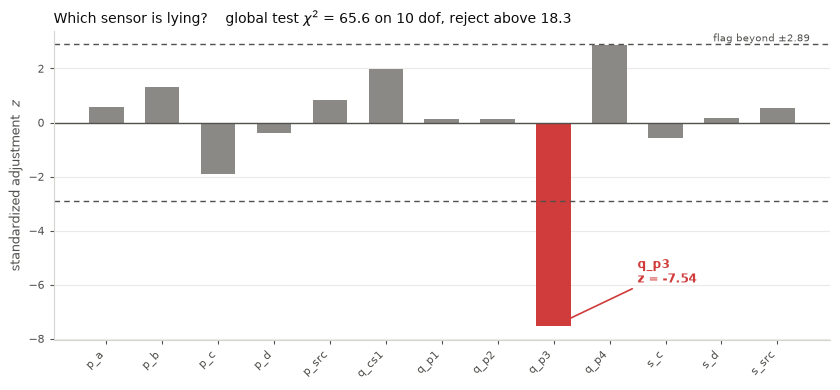

In [15]:
mt = measurement_test(res_bad)
gt = global_test(res_bad)
z = np.array([mt.z.get(n, np.nan) for n in names])

fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.bar(np.arange(len(names)), z, width=0.62, edgecolor="none",
       color=[RED if (np.isfinite(v) and abs(v) > mt.critical) else GREY for v in z])
for line in (mt.critical, -mt.critical):
    ax.axhline(line, color=INK_SOFT, linestyle=(0, (4, 3)), linewidth=1)
ax.axhline(0, color=INK_SOFT, linewidth=1)
ax.text(len(names) - 0.4, mt.critical, f" flag beyond $\\pm${mt.critical:.2f}",
        fontsize=7.5, color=INK_SOFT, va="bottom", ha="right")
ax.set_xticks(np.arange(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("standardized adjustment  $z$", fontsize=9, color=INK_SOFT)
ax.set_title(f"Which sensor is lying?    global test $\\chi^2$ = {gt.statistic:.1f} "
             f"on {gt.dof} dof, reject above {gt.critical:.1f}",
             fontsize=10, color=INK, loc="left")
i = names.index(mt.suspect)
ax.annotate(f"{mt.suspect}\nz = {z[i]:+.2f}", xy=(i, z[i]),
            xytext=(i + 1.5, z[i] + 2.0), fontsize=8.5, color=RED,
            fontweight="bold", ha="left", va="center",
            arrowprops=dict(arrowstyle="->", color=RED, linewidth=1.2))
tidy(ax)
plt.tight_layout()
plt.show()

The **global test** compares the reconciliation objective against $\chi^2$ on the degrees of
redundancy: it says *something* is wrong. The **measurement test** standardizes each
adjustment by its own standard deviation, $z_i = (\hat x_i - y_i)/\sqrt{\Sigma_{adj,ii}}$,
and points at the culprit --- here `q_p3` stands well clear of everything else.

Note that the second-largest $|z|$ belongs to an innocent sensor. That is smearing: the
adjustment had to go somewhere. **Serial elimination** discards the prime suspect and
re-tests.

In [16]:
for step in serial_elimination(
    residual_fn, y_bad, sigma,
    names=layout.names, unmeasured_scale=layout.default_scale,
):
    removed = step.removed or "(none)"
    verdict = "REJECT" if step.detected else "accept"
    print(f"removed {removed:<8} chi2 = {step.statistic:7.3f} on {step.dof:2d} dof "
          f"-> {verdict}   next suspect: {step.suspect}")

removed (none)   chi2 =  65.583 on 10 dof -> REJECT   next suspect: q_p3
removed q_p3     chi2 =   8.729 on  9 dof -> accept   next suspect: None


Discarding `q_p3` drops the statistic from rejection to a routine value, at the cost of one
degree of redundancy. The data are clean --- and the flow through `p3` is still estimated,
now from the balances alone rather than from a meter that was lying.

## 7. Estimating an unmeasured fouling factor

Pipes foul. Their effective resistance drifts above the design value, and nobody measures
it directly. In this framework an unknown parameter is simply a variable with **no
measurement**: give it $\sigma = \infty$ and it is estimated rather than reconciled, in the
same solve, with a standard error from the same covariance matrix.

Add an efficiency multiplier $\eta$ on `p3`, where $\eta > 1$ means *more* resistance.

In [17]:
# a network whose p3 really is 15% more resistive than the model believes
fouled = dg.GasNetwork(
    arcs=net.arcs,
    beta={**net.beta, "p3": net.beta["p3"] * 1.15},
    supply_kg_s=net.supply_kg_s,
)
fs_f, dec_f = dg.build_network_flowsheet(
    fouled, root="src", p_slack_pa=P_SLACK_PA, ratios=RATIOS
)
st_f = fs_f.solve(tol=1e-12, max_iter=500)

layout_eta = dg.gas_state_layout(net, efficiency_arcs=["p3"])
sigma_eta = dg.measurement_sigma(layout_eta)        # eta defaults to unmeasured

x_fouled = layout_eta.pack(
    verify.node_pressures_bar(st_f, dec_f),
    verify.arc_flows_kg_s(st_f, dec_f),
    fouled.supply_kg_s,
    {"eta_p3": 1.0},
)
y_fouled = dg.perturb(x_fouled, sigma_eta, jax.random.PRNGKey(3))

# the residual model still uses the CLEAN beta, so eta must absorb the fouling
res_eta = dg.reconcile_network(net, y_fouled, sigma_eta, layout_eta, ratios=RATIOS)

eta, sd = res_eta.x_named["eta_p3"], res_eta.std["eta_p3"]
print(f"estimated eta_p3 = {eta:.4f} +- {sd:.4f}   (true value 1.15)")
print(f"that is {abs(eta - 1.15) / sd:.2f} standard errors from the truth")
print(f"\ndegrees of redundancy: {res_eta.structure.degree_of_redundancy} "
      f"(estimating a parameter costs one)")

estimated eta_p3 = 1.1337 +- 0.0487   (true value 1.15)
that is 0.34 standard errors from the truth

degrees of redundancy: 9 (estimating a parameter costs one)


The fouling is recovered from pressures and flows that never mention it, with an honest
uncertainty attached. Nothing about this was a separate "parameter estimation" step ---
it is the same least-squares problem with one fewer weight.

The complementary question is what happens to the reconciled state if a *fixed* parameter
changes. That is a derivative, not an estimate, and `params` supplies it:

In [18]:
def q_p3_hat(efficiency):
    """Reconciled flow through p3 as a function of its fouling factor."""
    x, _ = solve_reconciliation(
        residual_fn, y, sigma, x0=x_true,
        scaling=res.scaling, params={"p3": efficiency}, n_steps=12,
    )
    return x[layout.index("q_p3")]

print(f"q_p3 at eta = 1.0      : {float(q_p3_hat(1.0)):.4f} kg/s")
print(f"d q_p3 / d eta         : {float(jax.grad(q_p3_hat)(1.0)):.4f} kg/s per unit eta")

q_p3 at eta = 1.0      : 55.6231 kg/s


d q_p3 / d eta         : -14.3876 kg/s per unit eta


Negative, as it must be: a dirtier pipe carries less of the loop's flow. The gradient runs
through the entire reconciliation --- the Gauss-Newton iteration, the KKT solves, the
constraint Jacobian --- by the implicit function theorem.

## 8. Where estimation stops working

You cannot estimate everything. The KKT system is nonsingular if and only if the *unmeasured*
columns of the Jacobian have full column rank --- which is exactly the classical
observability condition of data reconciliation. Solvability and observability are one test,
and it runs before the solve, so an ill-posed problem is diagnosed rather than returning
`NaN`.

Un-meter the whole loop --- three flows and three pressures --- while still asking for
$\eta$:

In [19]:
LOOP = ["q_p2", "q_p3", "q_p4", "p_b", "p_c", "p_d"]

sigma_blind = dg.measurement_sigma(layout_eta, unmeasured=LOOP)
try:
    dg.reconcile_network(net, y_fouled, sigma_blind, layout_eta, ratios=RATIOS)
except ReconciliationStructureError as err:
    print(err)

reconciliation problem is not solvable: 1 unmeasured variable(s) cannot be determined from the constraints. Unobservable: eta_p3. (10 equations, 7 measured and 7 unmeasured variables; rank(A)=10, rank(A_unmeasured)=6). Measure one of the variables above, give it a finite sigma as a prior, or remove it from the state.


Now drop $\eta$ and un-meter *the same six loop variables*:

In [20]:
sigma_loop = dg.measurement_sigma(layout, unmeasured=LOOP)
res_loop = dg.reconcile_network(net, y, sigma_loop, layout, ratios=RATIOS)

print(f"solvable: {res_loop.structure.solvable}, "
      f"degrees of redundancy: {res_loop.structure.degree_of_redundancy}")
for name in LOOP:
    print(f"  {name:<6} = {res_loop.x_named[name]:8.3f}  +- {res_loop.std[name]:.3f}")

solvable: True, degrees of redundancy: 4
  q_p2   =   64.532  +- 0.383
  q_p3   =   55.935  +- 0.329
  q_p4   =   16.259  +- 0.871
  p_b    =   61.884  +- 0.277
  p_c    =   57.349  +- 0.312
  p_d    =   56.747  +- 0.317


Six unknowns are recoverable; seven are not. And the reason the six work is the compressor:
$p_b = 1.2\,p_a$ ties the loop's pressures to the measured pressure upstream of the station.
Remove that equation --- as `verify` does, quite reasonably, for a sequential solve --- and
the loop floats free.

The classification is available directly, for any variable:

In [21]:
print(res_loop.structure.summary())

degrees of redundancy : 4
equations             : 10
measured / unmeasured : 7 / 6
solvable              : True

variable             class                        redundancy
------------------------------------------------------------
p_a                  measured-redundant                0.408
p_b                  unmeasured-observable                  
p_c                  unmeasured-observable                  
p_d                  unmeasured-observable                  
p_src                measured-redundant                0.553
q_cs1                measured-redundant                0.640
q_p1                 measured-redundant                0.640
q_p2                 unmeasured-observable                  
q_p3                 unmeasured-observable                  
q_p4                 unmeasured-observable                  
s_c                  measured-redundant                0.460
s_d                  measured-redundant                0.460
s_src                measured-red

### Estimating anyway, with a prior

Failing is not the only option. A *finite* $\sigma$ on an unmetered variable is a Bayesian
prior, and costs nothing extra --- it is simply another measured entry. Instead of raising,
a weakly identified parameter shrinks toward its prior.

Be careful what you conclude from it, though.

In [22]:
sigma_prior = dg.measurement_sigma(
    layout_eta, unmeasured=LOOP, sigma_eta=0.1     # a 10% prior on the fouling
)
res_prior = dg.reconcile_network(
    net, y_fouled, sigma_prior, layout_eta, ratios=RATIOS
)
print(f"eta_p3 = {res_prior.x_named['eta_p3']:.4f} +- {res_prior.std['eta_p3']:.4f}")
print(f"prior was          1.0000 +- 0.1000")
print(f"truth is           1.1500")
print(f"\ninformation gained from the data: "
      f"{100 * (1 - (res_prior.std['eta_p3'] / 0.1) ** 2):.1f}% of the prior variance")

eta_p3 = 1.0000 +- 0.1000
prior was          1.0000 +- 0.1000
truth is           1.1500

information gained from the data: 0.0% of the prior variance


The posterior is the prior, exactly --- and it is *wrong*, because the truth is 1.15.

With the loop unmetered the data say nothing whatever about $\eta$, so reconciliation
returns what you told it to believe. This is the honest failure mode of a prior: it converts
an error you would have noticed into an answer you might not question. The standard error is
the tell --- no reduction means no information --- and the fix is not a better prior but a
meter.

## 9. Which sensor should you buy?

The value of a meter is not its own accuracy but how much it sharpens the quantity you care
about --- a question the covariance answers before any money is spent. Rank candidate
sensors by their effect on the fouling estimate, starting from the blind-loop case above.

In [23]:
ranked = sensor_ranking(
    dg.network_residual_fn(net, layout_eta, ratios=RATIOS),
    x_fouled, sigma_prior,
    target="eta_p3", candidates=LOOP, candidate_sigma=1.0,
    names=layout_eta.names,
)

print(f"{'add a meter on':<16} {'sd(eta)':>10} {'variance reduction':>20}")
print("-" * 50)
for d in ranked:
    print(f"{d['candidate']:<16} {d['sd_before']:.4f} -> {d['sd_after']:.4f}"
          f" {100 * d['variance_reduction']:14.1f} %")

add a meter on      sd(eta)   variance reduction
--------------------------------------------------
q_p3             0.1000 -> 0.0661           56.3 %
q_p2             0.1000 -> 0.0666           55.7 %
q_p4             0.1000 -> 0.0741           45.1 %
p_d              0.1000 -> 0.0968            6.4 %
p_c              0.1000 -> 0.0985            2.9 %
p_b              0.1000 -> 0.1000            0.0 %


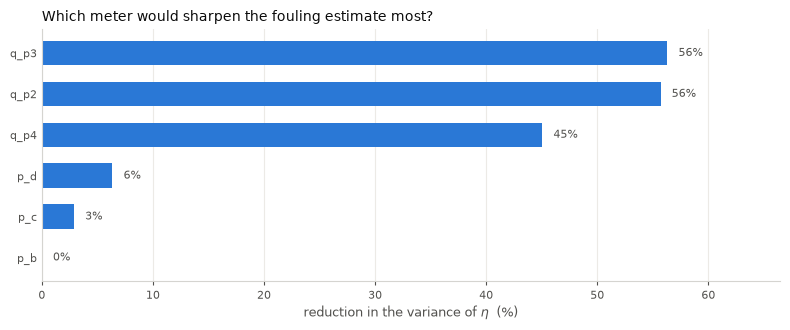

In [24]:
fig, ax = plt.subplots(figsize=(8, 3.4))
cand = [d["candidate"] for d in ranked][::-1]
red = [100 * d["variance_reduction"] for d in ranked][::-1]
ax.barh(np.arange(len(cand)), red, height=0.6,
        color=[BLUE if v > 1 else GREY for v in red], edgecolor="none")
ax.set_yticks(np.arange(len(cand)))
ax.set_yticklabels(cand, fontsize=8.5)
ax.set_xlabel("reduction in the variance of $\\eta$  (%)", fontsize=9, color=INK_SOFT)
ax.set_title("Which meter would sharpen the fouling estimate most?",
             fontsize=10, color=INK, loc="left")
for i, v in enumerate(red):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=8, color=INK_SOFT)
ax.set_xlim(0, max(red) * 1.18)
tidy(ax, axis="x")
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

The loop **flow** meters are worth far more than the pressure transmitters, and `p_b` is
worth nothing at all --- it is already pinned by the compressor relation, so measuring it
adds no information. That is the kind of conclusion that is expensive to reach empirically
and nearly free to compute.

## Summary

| Question | Answer | Where it comes from |
|---|---|---|
| Do the measurements fit the model? | Global $\chi^2$ test on the objective | `global_test` |
| What are the true values? | Constrained WLS via the KKT system | `reconcile` |
| How good are the estimates? | $\Sigma_{\hat x} = [K^{-1}]_{11}$ | `res.covariance`, `res.std` |
| Which sensor is lying? | Standardized adjustments | `measurement_test`, `serial_elimination` |
| What is the unknown parameter? | Give it $\sigma = \infty$ | same solve |
| Can it be known at all? | $\operatorname{rank}(A_U)$, before solving | `res.structure` |
| Which meter should we add? | Covariance with and without | `sensor_ranking` |
| Is the *model* the thing that drifted? | The same tests, read over many days | `monitor_network`, `reconcile_network_multi` |

**What the differentiability bought**

1. The constraint Jacobian is `jax.jacobian(F)` --- no hand-derived analytical model per unit.
2. Gradients run *through* the reconciliation, so `d(estimate)/d(parameter)` is one `jax.grad` call.
3. Covariance can be obtained two independent ways, and their disagreement measures the model's nonlinearity rather than a bug.
4. Joint parameter estimation is not a separate algorithm --- it is one weight set to zero.

**Practical notes**

- Solve in **bar and bar²**, not Pa. The KKT matrix mixes $W$ (1/variable²) with $A$ (residual/variable), so its conditioning depends on the unit system; automatic scaling makes the result unit-invariant and is on by default.
- Boundary flows belong in the **state**, not in the `GasNetwork`. Real nominations do not sum to zero, which is the whole point.
- Redundancy is uneven. A gross error on a weakly redundant sensor (`q_p4` here) may be misattributed to its neighbours --- check the ranked $z$ scores, not just the top one.

**Next**

Everything above is one snapshot, and it takes the model as correct. [`29_model_updating.ipynb`](29_model_updating.ipynb) runs the same tests over a 45-day campaign, where the question inverts: the global test rejects, but is a sensor lying or has the *model* drifted? A single day cannot tell --- `monitor_network` and `diagnose()` read the answer off the series --- and once you are entitled to re-estimate a parameter, `reconcile_network_multi` pools the window into one solve instead of averaging daily estimates.